# Row 5: More same-day-expiry gamma at 15:30, quieter close; the same-day layer is larger than the standing book

| field | content |
|---|---|
| frequency (GEX period) | live value at a 30-minute close with the true remaining time to expiry |
| strength | 0.31 Spearman correlation |
| tradability (1 to 10) | 4 |
| holds for | yes SPY, QQQ (1.44 versus 1.09, p-value 0.006), IWM (1.27 versus 1.04, p-value 0.005), TSLA (p-value 0.02), MSFT (p-value 0.04); no NVDA, AAPL, AMZN, META, AMD. Stocks expire weekly, so about 112 days each |
| how to trade | on days in the top third of same-day gamma at 15:30, sell the last-half-hour straddle or expect a pinned close |
| numbers (SPY) | 15:30 to 16:00 range 1.07 versus 1.59 times the median, t-statistic -2.4 after controlling for the day's range so far; the same-day layer holds 5.6 billion dollars of unsigned gamma exposure at 10:00 against 4.2 billion for the whole standing book, 57% of the total; that open interest doubles on the last day before expiry |
| example | 2025-07-02: 7.5 billion dollars of same-day exposure at 15:30, standing book +4.1 billion, last half hour 0.60 times the median |
| video opener | More than half of the gamma alive in SPY on any day sits in options that expire that same afternoon, and the daily report never shows them because they are gone by the close. When that same-day gamma is large going into 15:30, the last half hour tends to be quiet. Plan how you trade the close around a number only a live calculation can give you. |

In [1]:
import sys
import json
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
sys.path.insert(0, "../gex_history")
import rows as R
import gexlib as G
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
ctx = R.load("spy", with_chain=True)
print(ctx["sym"], len(ctx["daily"]), "days")

SPY 751 days


{
 "n_day_buckets": 9659,
 "n_days": 743,
 "median_contracts_per_day": 68.0,
 "spearman_next_range": {
  "stale": -0.4287268803677415,
  "live": -0.5179344148479462,
  "live_plus_0dte_signed": -0.514346404884229,
  "unsigned_0dte_alone": -0.29368179924284027,
  "signed_0dte_alone": -0.3601872880549699
 },
 "joint_regression_t": {
  "live_rank": -13.018570111683298,
  "u0dte_rank": -5.445905091726211,
  "s0dte_rank": 0.21498317113983817
 },
 "joint_regression_coef": {
  "live_rank": -1.1926951964374146,
  "u0dte_rank": -0.6188026048881037,
  "s0dte_rank": 0.01466538672532553
 },
 "last_half_hour_by_0dte_exposure_at_1530": {
  "prev_positive": {
   "n": 310,
   "last_half_hour_range_adj_low_0dte": 1.1178180335229608,
   "high_0dte": 0.8767856429777925,
   "diff_high_minus_low": -0.24103239054516834,
   "ci_lo": -0.4180875855741599,
   "ci_hi": -0.07841796656660283,
   "p_mwu": 0.0010981253200143697,
   "spearman_ugex_vs_last_range": -0.22572548672085138,
   "spearman_signed_vs_last_range

,ugex_0dte_bn,book_abs_bn,share_0dte,net_0dte_positive_share
bucket,,,,
0,5.600,4.202,0.598,0.598
1,5.608,4.229,0.591,0.579
2,5.464,4.374,0.583,0.573
3,5.488,4.346,0.586,0.580
4,5.431,4.409,0.586,0.600
5,5.403,4.508,0.578,0.590
6,5.423,4.514,0.572,0.579
7,5.359,4.490,0.566,0.592
8,5.418,4.525,0.565,0.583


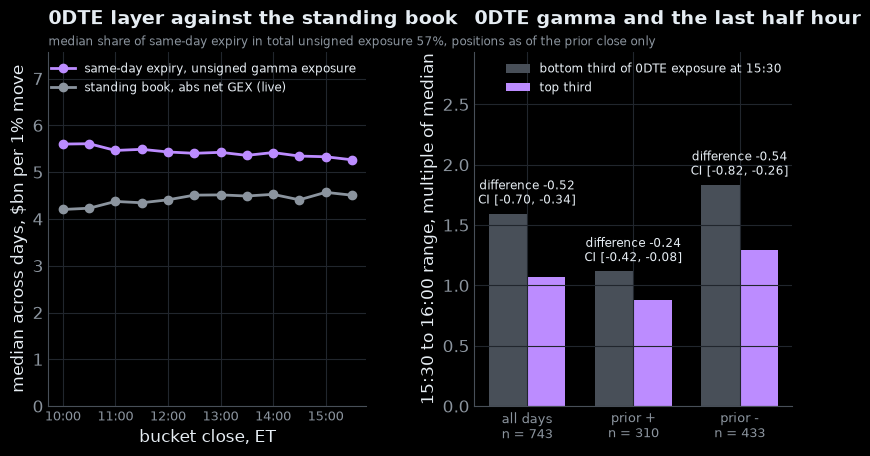

In [2]:
res = R.row5(ctx)
print(json.dumps({k: v for k, v in R.show(res['t8']).items() if k != 'by_bucket'}, indent=1))
print(json.dumps(R.show(res['controls']), indent=1))
display(pd.DataFrame(res['t8']['by_bucket']).set_index('bucket').round(3))
_ = R.fig5(ctx, res, G.FIGURES / 'row05_zero_dte.png')

In [3]:
R.per_name({'r5_days_with_0dte': 'days with a same-day expiry', 'r5_share_0dte_of_book_1000': 'same-day-expiry share of gamma at 10:00', 'r5_spearman_1530_last': 'Spearman correlation, 15:30 exposure versus last half hour', 'r5_last_low': 'last half hour, low third (times the median)', 'r5_last_high': 'last half hour, high third', 'r5_last_p': 'p-value'}).round(3)

,days with a same-day expiry,same-day-expiry share of gamma at 10:00,"Spearman correlation, 15:30 exposure versus last half hour","last half hour, low third (times the median)","last half hour, high third",p-value
symbol,,,,,,
SPY,743,0.598,-0.306,1.595,1.073,0.000
QQQ,248,0.588,-0.152,1.442,1.087,0.006
IWM,248,0.308,-0.139,1.268,1.036,0.005
NVDA,111,0.391,0.012,1.073,1.121,0.854
TSLA,112,0.623,-0.216,1.283,1.129,0.022
AAPL,114,0.345,-0.124,1.175,1.190,0.282
AMZN,114,0.344,-0.150,1.235,1.030,0.182
META,112,0.531,-0.201,1.105,1.077,0.205
MSFT,112,0.433,-0.223,1.407,1.086,0.039
